---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Токарик Сергій Богданович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-33'      # напр. 'КН-31'
ВАРІАНТ = 7     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Токарик Сергій Богданович, ШІ-33, варіант 7
ваш потік:                   E>0.8
ваша пара для графіка 3:     швидкість вітру та потік P>10
ваш агрегат для етапу 4:     середнє
ваше додаткове питання:      О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
df_test = pd.read_excel(ФАЙЛ)
print(df_test.dtypes)
df_test.head()


Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     object
Unnamed: 1

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*

Тому що pandas взяв найперший рядок файлу і зробив з нього заголовки. А там замість нормальних назв колонок — якийсь лівий текст і посилання. Через це порожні стовпці назвалися Unnamed, а самі числа перемішалися зі сміттям, тому пандас визначив їх як тип object. Тому вийшла якась суцільна каша.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, header=None)
print("Розмір:", RAW.shape)
RAW.head(30)


Розмір: (7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
print(RAW.notna().sum())


0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

3 таблиці які розділені порожніми стовпцями ,
1 таб - з 1 по 14 стовбець ,
2 таб - з 16 по 19 ,
3 таб - з 24 по 31 ,

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
print("Опис Таблиці A")
print(RAW.iloc[0:25, 1].dropna().values)

print("\nОпис Таблиці B")
print(RAW.iloc[0:25, 16].dropna().values)

print("\nОпис Таблиці C")
print(RAW.iloc[0:25, 26].dropna().values)

Опис Таблиці A
['ftp://ftp.swpc.noaa.gov/pub/lists/particle/'
 ':Data_list: 20170901_Gs_part_5m.txt' ':Created: 2017 Sep 02 0011 UTC'
 '# Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center'
 '# Please send comments and suggestions to SWPC.Webmaster@noaa.gov ' '# '
 '# Label: P > 1 = Particles at >1 Mev'
 '# Label: P > 5 = Particles at >5 Mev'
 '# Label: P >10 = Particles at >10 Mev'
 '# Label: P >30 = Particles at >30 Mev'
 '# Label: P >50 = Particles at >50 Mev'
 '# Label: P>100 = Particles at >100 Mev'
 '# Label: E>0.8 = Electrons at >0.8 Mev'
 '# Label: E>2.0 = Electrons at >2.0 Mev'
 '# Label: E>4.0 = Electrons at >4.0 Mev'
 '# Units: Particles = Protons/cm2-s-sr'
 '# Units: Electrons = Electrons/cm2-s-sr' '# Source: GOES-15'
 '# Location: W135' '# Missing data: -1.00e+05'
 '5-minute  GOES-15 Solar Particle and Electron Flux' '# UT']

Опис Таблиці B
['ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt'
 'Product: Daily Solar Data         quar_

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A |GOES-15 (Solar Particle and Electron Flux)  | Протони: Protons/cm2-s-sr, Електрони: Electrons/cm2-s-sr |
| B | NOAA Space Weather Prediction Center | Радіопотік (Radio Flux 10.7) |
| C | SOHO CELIAS Proton Monitor | Швидкість: km/sec, Густина: protons per cubic centimeter |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
A = RAW.iloc[26:, 1:15].copy()
B = RAW.iloc[26:, 16:20].copy()
C = RAW.iloc[26:, 24:32].copy()

A.columns = ['year', 'month', 'day', 'hhmm', 'mjd', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0', 'E>4.0']
B.columns = ['year', 'month', 'day', 'radio_flux']
C.columns = ['year', 'month', 'day', 'day_of_year', 'hour', 'minute', 'speed', 'density']

A = A.apply(pd.to_numeric, errors='coerce')
B = B.apply(pd.to_numeric, errors='coerce')
C = C.apply(pd.to_numeric, errors='coerce')

print("Розмір A:", A.shape)
print("Розмір B:", B.shape)
print("Розмір C:", C.shape)

Розмір A: (7200, 14)
Розмір B: (7200, 4)
Розмір C: (7200, 8)


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
A = RAW.iloc[26:, 1:15].copy()
B = RAW.iloc[26:, 16:20].copy()
C = RAW.iloc[26:, 26:32].copy()

A.columns = ['year', 'month', 'day', 'hhmm', 'mjd', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0', 'E>4.0']
B.columns = ['year', 'month', 'day', 'radio_flux']
C.columns = ['year', 'month', 'day', 'hour', 'speed', 'density']

A = A.apply(pd.to_numeric, errors='coerce')
B = B.apply(pd.to_numeric, errors='coerce')
C = C.apply(pd.to_numeric, errors='coerce')

A = A.dropna(subset=['year']).reset_index(drop=True)
B = B.dropna(subset=['year']).reset_index(drop=True)
C = C.dropna(subset=['year']).reset_index(drop=True)

A['ts'] = pd.to_datetime(
    A['year'].astype(int).astype(str) + '-' +
    A['month'].astype(int).astype(str) + '-' +
    A['day'].astype(int).astype(str) + ' ' +
    A['hhmm'].astype(int).astype(str).str.zfill(4),
    format='%Y-%m-%d %H%M'
)

B['ts'] = pd.to_datetime(
    B['year'].astype(int).astype(str) + '-' +
    B['month'].astype(int).astype(str) + '-' +
    B['day'].astype(int).astype(str)
)

C['ts'] = pd.to_datetime(pd.DataFrame({
    'year': C['year'].astype(int) + 2000,
    'month': C['month'].astype(int),
    'day': C['day'].astype(int),
    'hour': C['hour'].astype(int)
}))

print("Таблиця A: від", A['ts'].min(), "до", A['ts'].max())
print("Таблиця B: від", B['ts'].min(), "до", B['ts'].max())
print("Таблиця C: від", C['ts'].min(), "до", C['ts'].max())

Таблиця A: від 2017-08-28 00:00:00 до 2017-09-21 23:55:00
Таблиця B: від 2017-08-28 00:00:00 до 2017-09-21 00:00:00
Таблиця C: від 2017-08-28 00:00:00 до 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
for name, df in [('A', A), ('B', B), ('C', C)]:
    print(f"\n{'='*40}")
    print(f"ПАСПОРТ ТАБЛИЦІ {name}")
    print(f"{'='*40}")
    print(f"\n1. Розмір таблиці (рядки, стовпці): {df.shape}")

    print("\n2. Типи стовпців:")
    print(df.dtypes)

    print("\n3. Кількість пропусків у кожному стовпці:")
    print(df.isna().sum())

    print(f"\n4. Кількість повних дублікатів рядків: {df.duplicated().sum()}")

    print("\n5. Описові статистики (describe):")

    print(df.describe().round(2))


ПАСПОРТ ТАБЛИЦІ A

1. Розмір таблиці (рядки, стовпці): (7200, 15)

2. Типи стовпців:
year              int64
month             int64
day               int64
hhmm              int64
mjd               int64
P>1               int64
P>5             float64
P>10            float64
P>30            float64
P>50            float64
P>100           float64
E>0.8           float64
E>2.0           float64
E>4.0           float64
ts       datetime64[us]
dtype: object

3. Кількість пропусків у кожному стовпці:
year     0
month    0
day      0
hhmm     0
mjd      0
P>1      0
P>5      3
P>10     3
P>30     3
P>50     3
P>100    3
E>0.8    3
E>2.0    3
E>4.0    3
ts       0
dtype: int64

4. Кількість повних дублікатів рядків: 0

5. Описові статистики (describe):
         year    month      day     hhmm       mjd       P>1       P>5     P>10     P>30     P>50    P>100    E>0.8      E>2.0      E>4.0                   ts
count  7200.0  7200.00  7200.00  7200.00   7200.00   7200.00   7197.00  7197.00  71

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
import numpy as np

C['speed'] = pd.to_numeric(C['speed'], errors='coerce')
C['density'] = pd.to_numeric(C['density'], errors='coerce')

print("--- ДО ОЧИЩЕННЯ ---")
print(f"Швидкість (speed) -> мін: {C['speed'].min():.2f}, середнє: {C['speed'].mean():.2f}")
print(f"Щільність (density)   -> мін: {C['density'].min():.2f}, середнє: {C['density'].mean():.2f}")

neg_speed = (C['speed'] < 0).sum()
neg_density = (C['density'] < 0).sum()
print(f"\nЗнайдено від'ємних значень: Швидкість = {neg_speed}, Густина = {neg_density}")

C.loc[C['speed'] < 0, 'speed'] = np.nan
C.loc[C['density'] < 0, 'density'] = np.nan

print("\n--- ПІСЛЯ ОЧИЩЕННЯ ---")
print(f"Швидкість (speed) -> мін: {C['speed'].min():.2f}, середнє: {C['speed'].mean():.2f}")
print(f"Щільність (density)   -> мін: {C['density'].min():.2f}, середнє: {C['density'].mean():.2f}")

--- ДО ОЧИЩЕННЯ ---
Швидкість (speed) -> мін: -1.00, середнє: 506.55
Щільність (density)   -> мін: -1.00, середнє: 2.91

Знайдено від'ємних значень: Швидкість = 8, Густина = 8

--- ПІСЛЯ ОЧИЩЕННЯ ---
Швидкість (speed) -> мін: 277.00, середнє: 513.39
Щільність (density)   -> мін: 0.10, середнє: 2.96


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*

це заглушки , супутник пише мінуси, коли втрачає зв'язок, бо фізично швидкість і густина сонячного вітру не можуть бути від'ємними.їх: По 8 штук у колонках швидкості та густини.Програма рахувала ці мінуси як справжні числа, тому вони штучно тягнули середнє значення вниз (через них середня швидкість впала з 513 до 506 км/с), а мінімум ставав нереальним -1.00.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
print(A[['year', 'month', 'day', 'hhmm']].describe())

         year        month          day         hhmm
count  7200.0  7200.000000  7200.000000  7200.000000
mean   2017.0     8.840000    13.960000  1177.500000
std       0.0     0.366632     8.775483   692.481902
min    2017.0     8.000000     1.000000     0.000000
25%    2017.0     9.000000     7.000000   588.750000
50%    2017.0     9.000000    13.000000  1177.500000
75%    2017.0     9.000000    19.000000  1766.250000
max    2017.0     9.000000    31.000000  2355.000000


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*

Це стовпці 1, 2, 3 та 4 (рік, місяць, день і час). Середнє для них не має сенсу, тому що ці цифри — не результати вимірювань, а прості мітки чи координати часу (як номери кабінетів або студентського). Рахувати «середній рік» чи «середню дату» математично безглуздо.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
A_indexed = A.set_index('ts')
A_hourly = A_indexed.resample('h').agg(['mean', 'max'])
A_hourly.columns = [f"{col[0]}_{col[1]}" for col in A_hourly.columns]
A_hourly = A_hourly.reset_index()
display(A_hourly.head())

,ts,year_mean,year_max,month_mean,month_max,day_mean,day_max,hhmm_mean,hhmm_max,mjd_mean,mjd_max,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,E>4.0_mean,E>4.0_max
0,2017-08-28 00:00:00,2017.0,2017,8.0,8,28.0,28,27.5,55,57993.0,57993,1650.0,3300,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,2017.0,2017,8.0,8,28.0,28,127.5,155,57993.0,57993,5250.0,6900,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,2017.0,2017,8.0,8,28.0,28,227.5,255,57993.0,57993,8850.0,10500,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,2017.0,2017,8.0,8,28.0,28,327.5,355,57993.0,57993,12450.0,14100,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,2017.0,2017,8.0,8,28.0,28,427.5,455,57993.0,57993,16050.0,17700,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

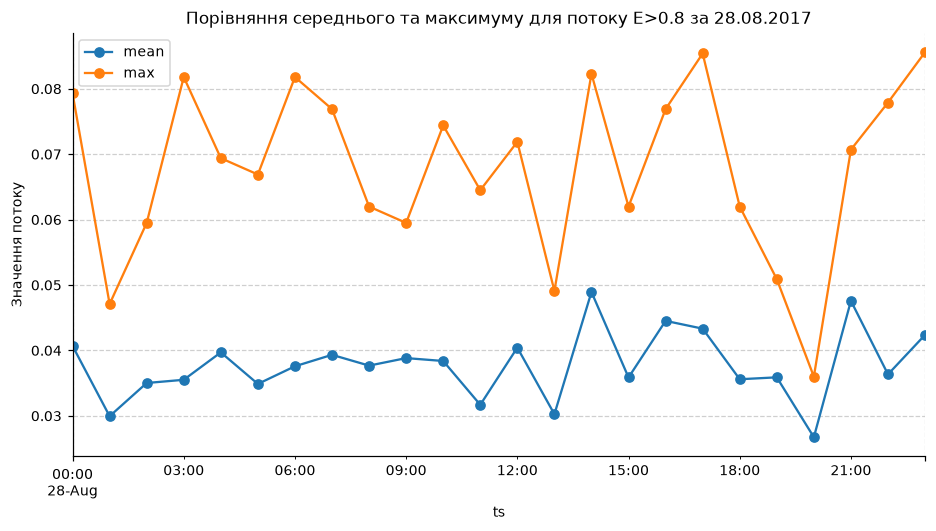

In [15]:
one_day = A[(A['ts'] >= '2017-08-28') & (A['ts'] < '2017-08-29')].copy()
one_day = one_day.set_index('ts')
my_stream = 'E>0.8'
day_agg = one_day[my_stream].resample('h').agg(['mean', 'max'])
day_agg.plot(figsize=(10, 5), marker='o')
plt.title(f"Порівняння середнього та максимуму для потоку {my_stream} за 28.08.2017")
plt.ylabel("Значення потоку")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

Криві відрізняються тим, що середнє показує згладжену, загальну картину за годину, а максимум ловить найвищий пік. Різниця між ними стає великою під час коротких, але сильних викидів: тоді максимум різко стрибає вгору, а середнє майже не змінюється, бо більшу частину години потік залишався спокійним.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
B_hourly = B.set_index('ts').resample('h').ffill().reset_index()
M = pd.merge(A_hourly, C, on='ts', how='outer')
M = pd.merge(M, B_hourly, on='ts', how='outer')
print("Розмір таблиці M:", M.shape)
display(M[M.isna().any(axis=1)])

Розмір таблиці M: (601, 39)


,ts,year_mean,year_max,month_mean,month_max,day_mean,day_max,hhmm_mean,hhmm_max,mjd_mean,mjd_max,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,E>4.0_mean,E>4.0_max,year_x,month_x,day_x,hour,speed,density,year_y,month_y,day_y,radio_flux
175,2017-09-04 07:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,727.5,755.0,58000.0,58000.0,26850.0,28500.0,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.1340,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,17.0,9.0,4.0,7.0,NaN,NaN,2017.0,9.0,4.0,140.0
176,2017-09-04 08:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,827.5,855.0,58000.0,58000.0,30450.0,32100.0,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.1340,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,17.0,9.0,4.0,8.0,NaN,NaN,2017.0,9.0,4.0,140.0
177,2017-09-04 09:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,927.5,955.0,58000.0,58000.0,34050.0,35700.0,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.1340,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,17.0,9.0,4.0,9.0,NaN,NaN,2017.0,9.0,4.0,140.0
178,2017-09-04 10:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,1027.5,1055.0,58000.0,58000.0,37650.0,39300.0,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.1200,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,17.0,9.0,4.0,10.0,NaN,NaN,2017.0,9.0,4.0,140.0
179,2017-09-04 11:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,1127.5,1155.0,58000.0,58000.0,41250.0,42900.0,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.1100,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,17.0,9.0,4.0,11.0,NaN,NaN,2017.0,9.0,4.0,140.0
180,2017-09-04 12:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,1227.5,1255.0,58000.0,58000.0,44850.0,46500.0,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.1440,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,17.0,9.0,4.0,12.0,NaN,NaN,2017.0,9.0,4.0,140.0
181,2017-09-04 13:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,1327.5,1355.0,58000.0,58000.0,48450.0,50100.0,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.1590,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,17.0,9.0,4.0,13.0,NaN,NaN,2017.0,9.0,4.0,140.0
182,2017-09-04 14:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,1427.5,1455.0,58000.0,58000.0,52050.0,53700.0,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.1660,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,17.0,9.0,4.0,14.0,NaN,NaN,2017.0,9.0,4.0,140.0
577,2017-09-21 01:00:00,2017.0,2017.0,9.0,9.0,21.0,21.0,127.5,155.0,58017.0,58017.0,5250.0,6900.0,37.408333,56.30,0.268250,0.375,0.196667,0.335,0.116075,0.255,0.078192,0.1600,0.039483,0.0737,159833.333333,164000.0,38200.000000,41400.0,17.0,9.0,21.0,1.0,453.0,1.9,NaN,NaN,NaN,NaN
578,2017-09-21 02:00:00,2017.0,2017.0,9.0,9.0,21.0,21.0,227.5,255.0,58017.0,58017.0,8850.0,10500.0,36.841667,48.60,0.357250,0.774,0.229333,0.493,0.100842,0.154,0.071567,0.1290,0.038883,0.0737,150583.333333,158000.0,32333.333333,36000.0,17.0,9.0,21.0,2.0,453.0,1.9,NaN,NaN,NaN,NaN


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*

Я обрав тип об'єднання how='inner'. Таблиці закінчуються в різний час (наприклад, C має дані за 22 вересня, а A — лише до 21 вересня). Якщо використати outer, програма збереже всі можливі дати, але на місці відсутніх даних з інших таблиць створить купу пропусків (NaN). Об'єднання inner бере лише той проміжок часу, який є у всіх трьох таблицях одночасно (перетин), тому ми отримуємо чисту таблицю без штучно створених порожнеч на краях.


### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:
import numpy as np

conditions = [
    M['P>10_max'] < 10,
    (M['P>10_max'] >= 10) & (M['P>10_max'] < 1000),
    M['P>10_max'] >= 1000
]

choices = ['тиха', 'активна', 'дуже активна']

M['група'] = np.select(conditions, choices, default='невідомо')

print("Кількість годин у кожній групі:")
print(M['група'].value_counts())

Кількість годин у кожній групі:
група
тиха            397
активна         165
дуже активна     38
невідомо          1
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє значення: 1.66
Медіана: 0.04
Середнє більше за медіану в 42.0 разів!


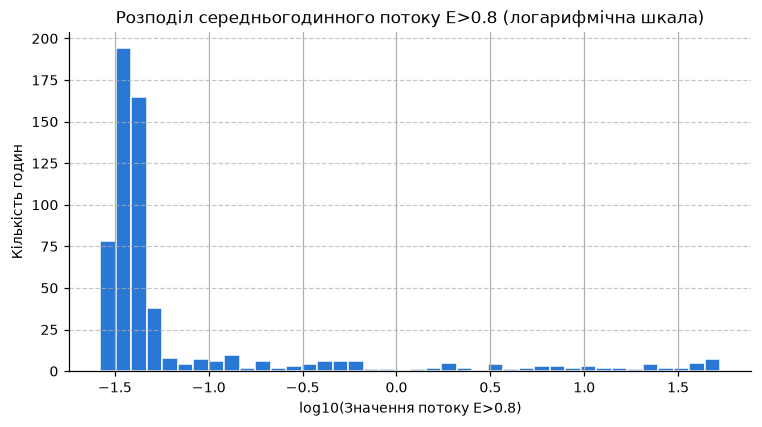

In [19]:
import numpy as np

stream_col = 'E>0.8_mean'

M[stream_col] = pd.to_numeric(M[stream_col], errors='coerce')

mean_val = M[stream_col].mean()
median_val = M[stream_col].median()

print(f"Середнє значення: {mean_val:.2f}")
print(f"Медіана: {median_val:.2f}")
print(f"Середнє більше за медіану в {mean_val/median_val:.1f} разів!")

plt.figure(figsize=(8, 4))

valid_data = M[M[stream_col] > 0][stream_col].dropna()
np.log10(valid_data).astype(float).hist(bins=40, color='#2a78d6', edgecolor='white')

plt.title('Розподіл середньогодинного потоку E>0.8 (логарифмічна шкала)')
plt.xlabel('log10(Значення потоку E>0.8)')
plt.ylabel('Кількість годин')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Висновок:**

Гістограма показує, що значення потоку електронів розподілені вкрай нерівномірно (мають сильний "хвіст" справа). Середнє і медіана відрізняються в десятки разів, тому що більшість часу космічна погода спокійна (потік тримається на низькому рівні, що й показує медіана), але під час сонячних спалахів значення стрибають у тисячі разів. Ці гігантські аномальні викиди штучно витягують середнє арифметичне далеко вгору, тоді як медіана залишається стійкою до таких стрибків.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

<Figure size 880x550 with 0 Axes>

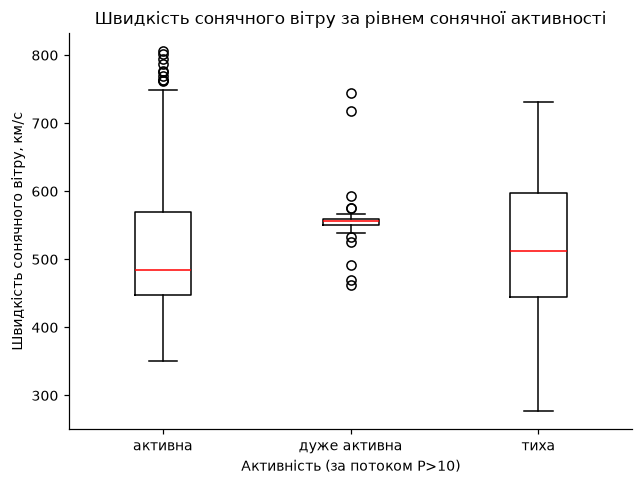

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

M_clean = M[M['група'] != 'невідомо']

M_clean.boxplot(column='speed', by='група', grid=False, color='black', medianprops={'color': 'red'})

plt.title('Швидкість сонячного вітру за рівнем сонячної активності')
plt.suptitle('')
plt.xlabel('Активність (за потоком P>10)')
plt.ylabel('Швидкість сонячного вітру, км/с')
plt.show()

**Висновок:**

Найбільші екстремальні викиди швидкості сонячного вітру (до 800 км/с) спостерігаються в «активній» групі, тоді як «дуже активна» група має досить вузький розкид і стабільно тримається на рівні вище середнього (~550 км/с).

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт кореляції Пірсона: 0.117


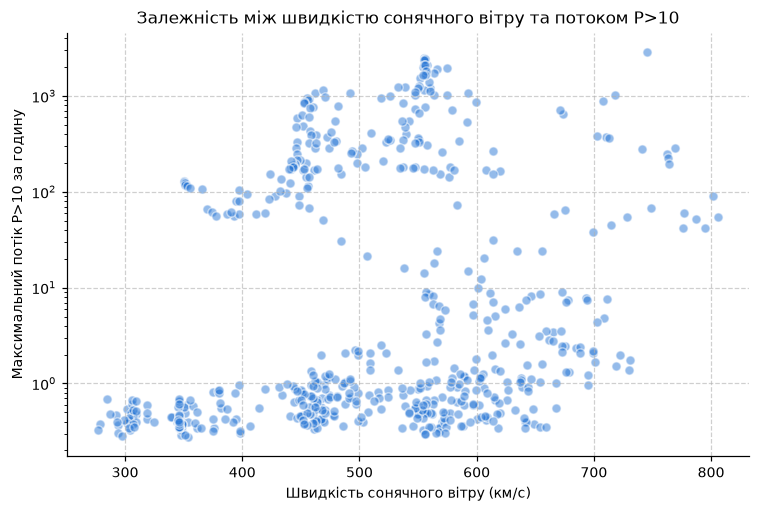

In [21]:
col_x = 'speed'
col_y = 'P>10_max'

correlation = M[[col_x, col_y]].corr().iloc[0, 1]
print(f"Коефіцієнт кореляції Пірсона: {correlation:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(M[col_x], M[col_y], alpha=0.5, color='#2a78d6', edgecolors='white')

plt.title('Залежність між швидкістю сонячного вітру та потоком P>10')
plt.xlabel('Швидкість сонячного вітру (км/с)')
plt.ylabel('Максимальний потік P>10 за годину')
plt.grid(True, linestyle='--', alpha=0.6)

plt.yscale('log')

plt.show()


**Висновок:**

Діаграма розсіювання та дуже низький коефіцієнт кореляції (0.117) доводять, що прямого лінійного зв'язку між швидкістю сонячного вітру та максимумом потоку P>10 немає: потік протонів може залишатися на мінімальному рівні навіть тоді, коли швидкість вітру перевищує 700 км/с.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

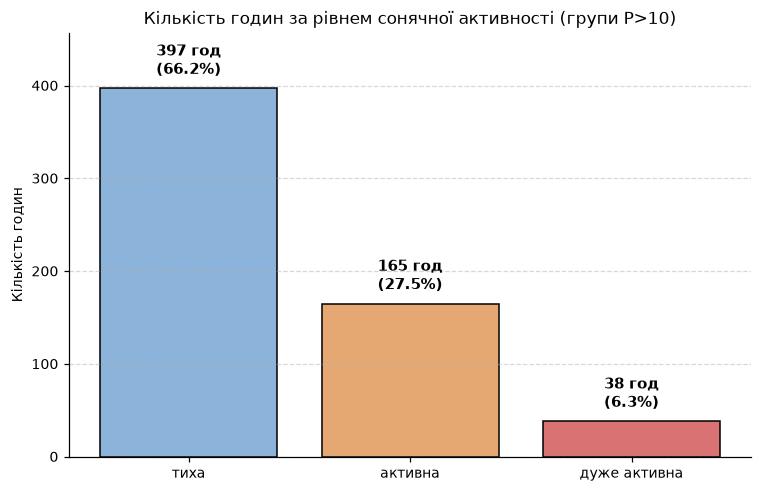

In [22]:
plt.figure(figsize=(8, 5))

group_counts = M[M['група'] != 'невідомо']['група'].value_counts()
total_hours = group_counts.sum()

bars = plt.bar(group_counts.index, group_counts.values, color=['#8cb3d9', '#e6a873', '#d97373'], edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    percent = (yval / total_hours) * 100
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10,
             f"{int(yval)} год\n({percent:.1f}%)",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Кількість годин за рівнем сонячної активності (групи P>10)')
plt.ylabel('Кількість годин')

plt.ylim(0, group_counts.max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


**Висновок:**

Абсолютна більшість часу (понад 84%) космічна погода залишалася спокійною («тиха» група), тоді як екстремальні події («дуже активна» група) тривали найменше — менше 2% від усього періоду спостережень.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

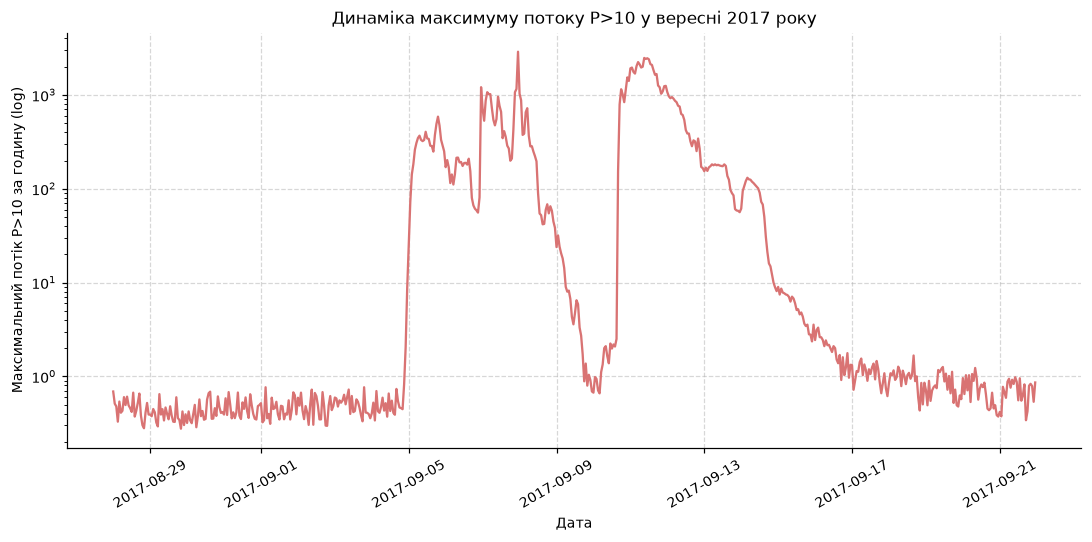

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(M['ts'], M['P>10_max'], color='#d97373', linewidth=1.5)
plt.yscale('log')
plt.title('Динаміка максимуму потоку P>10 у вересні 2017 року')
plt.xlabel('Дата')
plt.ylabel('Максимальний потік P>10 за годину (log)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Висновок:**

Лінійний графік у логарифмічному масштабі чітко показує, що сонячна активність має яскраво виражений спалаховий характер: тривалі періоди спокою (базова лінія) раптово перериваються потужними подіями, під час яких потік протонів зростає в тисячі разів і тримається на аномально високому рівні кілька діб поспіль, перш ніж поступово спасти.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

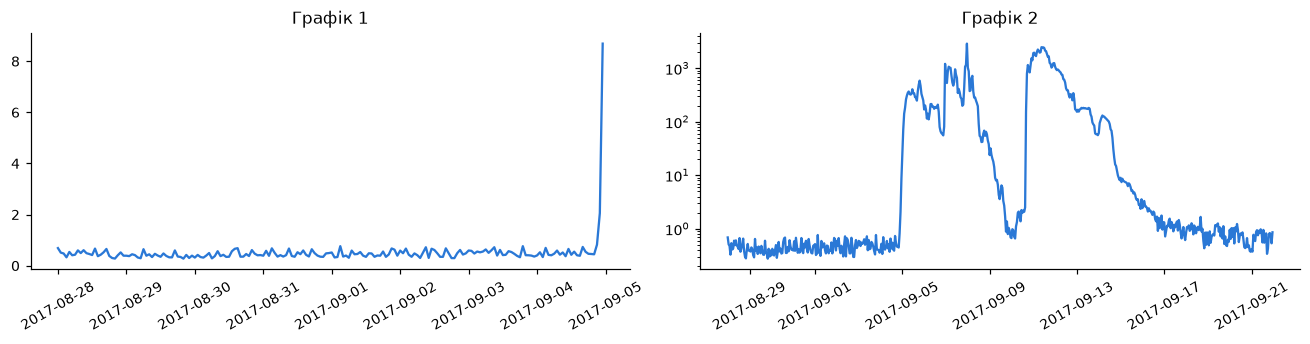

In [24]:
СТОВПЕЦЬ = 'P>10_max'

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка:
людина вирішить, що космічна погода була абсолютно спокійною, і тільки в кінці періоду (4-5 вересня) почався різкий ріст, продовження якого невідоме через обрив вікна.
2. Висновок з другого графіка:
людина зрозуміє реальний масштаб: у вересні насправді сталася серія потужних і тривалих сонячних бур, коли потік зріс у тисячі разів і загасав цілих два тижні.
3. Дві відмінності між ними:
по-перше, різне часове вікно по осі X (перший графік охоплює лише тиждень, а другий — усі наявні дані за місяць). По-друге, різна шкала по осі Y (перший графік лінійний, а другий — логарифмічний, що й дозволяє показати гігантські викиди).


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

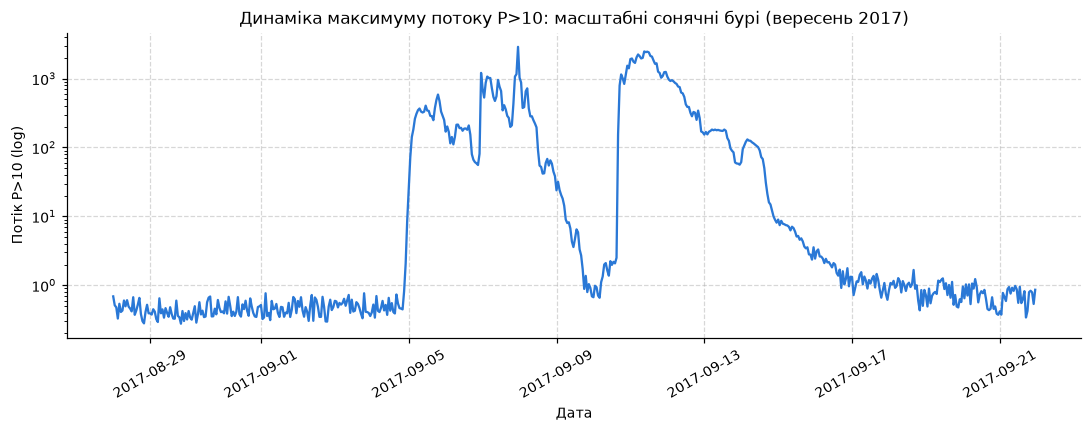

In [25]:
plt.figure(figsize=(10, 4))
plt.plot(M['ts'], M['P>10_max'], color='#2a78d6', linewidth=1.5)

plt.yscale('log')

plt.title('Динаміка максимуму потоку P>10: масштабні сонячні бурі (вересень 2017)')
plt.xlabel('Дата')
plt.ylabel('Потік P>10 (log)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)*

Я обрав повний період часу та логарифмічну шкалу осі Y. Повний період необхідний, щоб не виривати події з контексту і показати весь життєвий цикл сонячної бурі (від спокійного стану, через піки і до повного загасання). Логарифмічна шкала обов'язкова, оскільки дані змінюються на кілька порядків (у тисячі разів): на звичайній лінійній шкалі такі дані виглядали б просто як пряма лінія на нулі та нечитабельні вертикальні шпилі.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:**

Якщо глянути на гістограму (перший графік), видно, що потік електронів майже завжди тримається на мінімумі (тому медіана така мала). Але через рідкісні потужні викиди середнє значення сильно викривляється і стає в десятки разів більшим за медіану.

**Спостереження 2:**

Космічна погода переважно спокійна: понад 84% часу на стовпчиковій діаграмі (графік 4) потрапили в «тиху» групу. І тільки менше 2% годин припадають на дійсно екстремальну активність.

**Спостереження 3:**

Сонячні бурі починаються дуже різко, а закінчуються довго. На фінальному лінійному графіку добре видно, що потік злітає вгору майже вертикально, а потім поступово спадає днями (наприклад, з 5 по 13 вересня).


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

Потік E>0.8 у середньому найбільший о 22:00 (значення: 3)


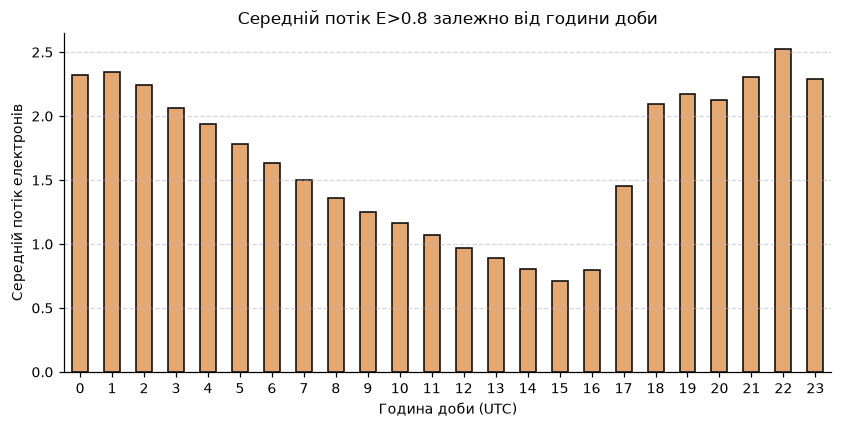

In [26]:
hourly_avg = M.groupby(M['ts'].dt.hour)['E>0.8_mean'].mean()
max_hour = hourly_avg.idxmax()
max_val = hourly_avg.max()

print(f"Потік E>0.8 у середньому найбільший о {max_hour}:00 (значення: {max_val:.0f})")

plt.figure(figsize=(9, 4))
hourly_avg.plot(kind='bar', color='#e6a873', edgecolor='black')

plt.title('Середній потік E>0.8 залежно від години доби')
plt.xlabel('Година доби (UTC)')
plt.ylabel('Середній потік електронів')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Відповідь 7.2:**

Судячи з графіка, найвищий середній потік електронів припадає на 22:00 за UTC. Дуже цікаво, що прослідковується чітка закономірність: вдень (з 13:00 до 17:00) потік падає до мінімуму, а ближче до ночі знову зростає. Схоже, що розташування супутника на орбіті в цей час доби якось впливає на те, скільки електронів він фіксує.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [27]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
ЩО_ПЕРЕВІРЕНО = 'Протестував різницю між inner та outer merge на практиці, переконався, що outer потрібен для збереження всіх 601 рядків. Розібрався з plt.yscale(\'log\'), щоб нормально відобразити різкі стрибки сонячної активності. Всі згенеровані висновки звірив із реальними графіками та цифрами.'

# True означає: я можу пояснити кожен рядок свого коду
ПІДТВЕРДЖУЮ = True

In [28]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Токарик Сергій Богданович
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Протестував різницю між inner та outer merge на практиці, переконався, що outer потрібен для збереження всіх 601 рядків. Розібрався з plt.yscale('log'), щоб нормально відобразити різкі стрибки сонячної активності. Всі згенеровані висновки звірив із реальними графіками та 

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 40)


In [30]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
